In [10]:
import pandas as pd
from arch import arch_model
import ccxt
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import time
import os
import json
from pathlib import Path
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [11]:
def fetch_all_data():
    exchange = ccxt.binance()
    symbol = 'BTC/USDT'
    timeframe = '1h'
    since = exchange.parse8601('2026-01-01T00:00:00Z')
    all_ohlcv = []

    while since < exchange.milliseconds():
        # Fetch a chunk (default is usually 500-1000)
        data = exchange.fetch_ohlcv(symbol, timeframe, since)
        if not data:
            break
        
        all_ohlcv.extend(data)
        
        # Update 'since' to the timestamp of the last candle + 1ms to get the next batch
        since = data[-1][0] + 1 
        
        # Avoid hitting rate limits
        time.sleep(exchange.rateLimit / 1000)

    df = pd.DataFrame(all_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df

In [12]:
df = fetch_all_data()
df.tail(5)

,open,high,low,close,volume
timestamp,,,,,
2026-04-08 17:00:00,71602.11,71963.94,71490.55,71888.19,682.09647
2026-04-08 18:00:00,71888.19,71888.20,71085.22,71099.63,703.75724
2026-04-08 19:00:00,71099.63,71372.22,71019.00,71318.48,473.49397
2026-04-08 20:00:00,71318.47,71481.70,71267.91,71372.93,226.24698
2026-04-08 21:00:00,71372.94,71582.53,71330.86,71545.00,108.64533


In [13]:
def get_returns(df):
    df['returns'] = df['close'].pct_change().dropna()
    ndf = df['returns'].dropna()
    
    return ndf

In [14]:
plotting_data = get_returns(df)
plotting_data.shape
print(plotting_data.head())

timestamp
2026-01-01 01:00:00    0.001717
2026-01-01 02:00:00   -0.000523
2026-01-01 03:00:00   -0.000773
2026-01-01 04:00:00   -0.002910
2026-01-01 05:00:00    0.001301
Name: returns, dtype: float64


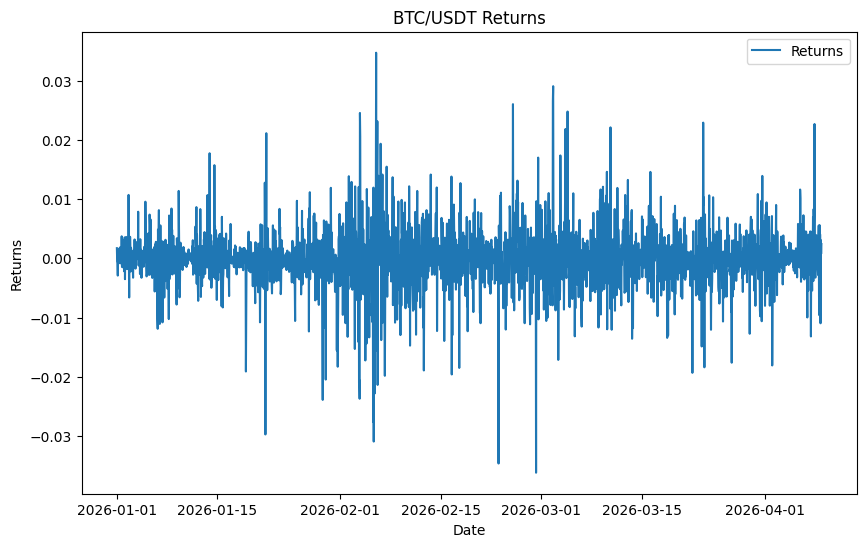

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(plotting_data, label='Returns')
ax.set_title('BTC/USDT Returns')
ax.set_xlabel('Date')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

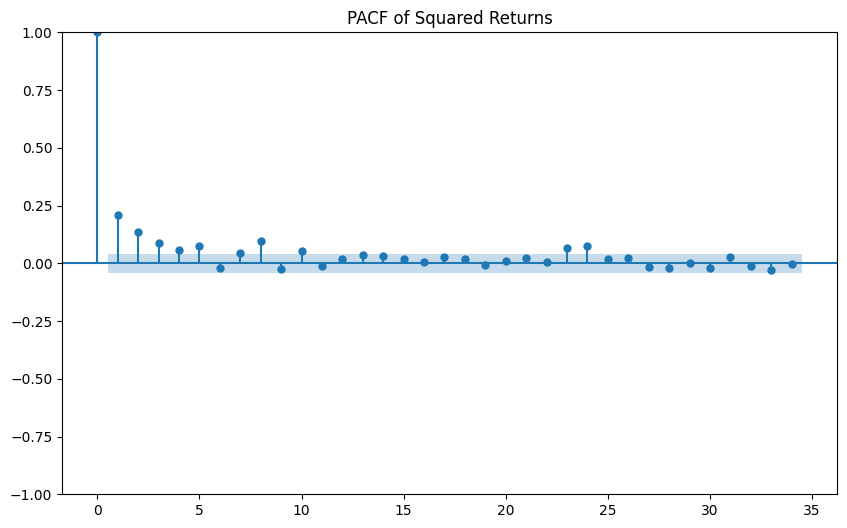

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_pacf(plotting_data**2, ax=ax)
ax.set_title('PACF of Squared Returns')
plt.show()

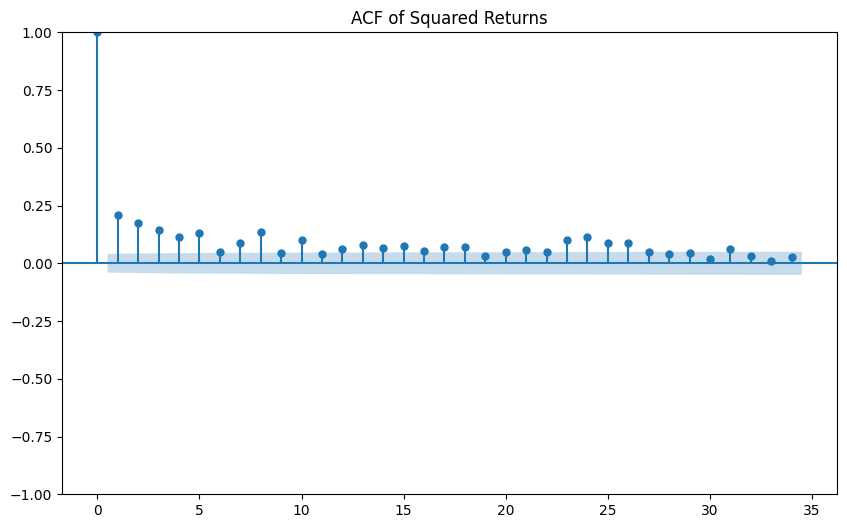

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(plotting_data**2, ax=ax)
ax.set_title('ACF of Squared Returns')
plt.show()

In [18]:
#cutoff = 0.8
train_size = int(len(plotting_data))
train_data = plotting_data[:train_size]
#test_data = plotting_data[train_size:]

In [24]:
import joblib
import json
from pathlib import Path

# Train model on scaled returns (p=1, q=1 for production)
model = arch_model(train_data, p=1, q=1, rescale=False)
model_fit = model.fit(disp='off')
print(model_fit.summary())

# Create model directory
model_dir = Path('model')
model_dir.mkdir(parents=True, exist_ok=True)

# Save with joblib using highest protocol for cross-version compatibility
artifact_path = model_dir / 'garch_btcusdt_1h.pkl'
joblib.dump(model_fit, artifact_path, protocol=5)
print(f"✓ Model saved to: {artifact_path.resolve()}")

# Also save model parameters as JSON fallback for reconstruction on version mismatch
params_path = model_dir / 'garch_btcusdt_1h_params.json'
params = {
    'p': 1,
    'q': 1,
    'rescale': False,
    'mu': float(model_fit.params.get('mu', 0)),
    'omega': float(model_fit.params.get('omega', 0)),
    'alpha[1]': float(model_fit.params.get('alpha[1]', 0)),
    'beta[1]': float(model_fit.params.get('beta[1]', 0)),
}
with open(params_path, 'w') as f:
    json.dump(params, f, indent=2)
print(f"✓ Parameters saved to: {params_path.resolve()}")
print("\n✓ Model is now portable across Python versions")

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                7266.16
Distribution:                  Normal   AIC:                          -14524.3
Method:            Maximum Likelihood   BIC:                          -14502.2
                                        No. Observations:                 1879
Date:                Thu, Apr 09 2026   Df Residuals:                     1878
Time:                        10:53:19   Df Model:                            1
                                   Mean Model                                  
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
mu         -5.0137e-05  5.708e-06     -8.783  1.5

In [ ]:
import os
import json
from pathlib import Path
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

# 1) Fit final model on train split
model = arch_model(train_data * 100, vol='Garch', p=1, q=1, rescale=False)
model_fit = model.fit(disp='off')
print(model_fit.summary())

# 2) Forecast variance over test horizon
h = len(test_data)
fc = model_fit.forecast(horizon=h, reindex=False)

# arch returns variance in percent-squared because we fit on returns*100.
# Convert back to variance of raw returns.
pred_var = (fc.variance.values[-1, :] / (100 ** 2)).astype(float)
pred_vol = np.sqrt(np.maximum(pred_var, 0.0))

# 3) Build a realized-volatility proxy from absolute returns
realized_vol = test_data.abs().to_numpy()

# Guard against length mismatch in edge cases
n = min(len(pred_vol), len(realized_vol))
pred_vol = pred_vol[:n]
realized_vol = realized_vol[:n]

mae = mean_absolute_error(realized_vol, pred_vol)
rmse = mean_squared_error(realized_vol, pred_vol) ** 0.5

# QLIKE loss for volatility forecasts
eps = 1e-12
rv2 = np.maximum(realized_vol ** 2, eps)
pv2 = np.maximum(pred_vol ** 2, eps)
qlike = float(np.mean(np.log(pv2) + (rv2 / pv2)))

metrics = {
    'horizon': int(n),
    'mae': float(mae),
    'rmse': float(rmse),
    'qlike': qlike,
}
print('Evaluation metrics:')
print(json.dumps(metrics, indent=2))

# 4) Persist trained model artifact with joblib (cross-version compatible)
model_dir = Path('model')
model_dir.mkdir(parents=True, exist_ok=True)
artifact_path = model_dir / 'garch_btcusdt_1h.pkl'

# Save with joblib using highest protocol
joblib.dump(model_fit, artifact_path, protocol=5)
print(f"✓ Model saved to: {artifact_path.resolve()}")

# Also save model parameters as JSON backup
params_path = model_dir / 'garch_btcusdt_1h_params.json'
params = {
    'p': 1,
    'q': 1,
    'rescale': False,
    'mu': float(model_fit.params.get('mu', 0)),
    'omega': float(model_fit.params.get('omega', 0)),
    'alpha[1]': float(model_fit.params.get('alpha[1]', 0)),
    'beta[1]': float(model_fit.params.get('beta[1]', 0)),
}
with open(params_path, 'w') as f:
    json.dump(params, f, indent=2)
print(f"✓ Parameters saved to: {params_path.resolve()}")
print("✓ Model is portable across Python versions")

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1385.47
Distribution:                  Normal   AIC:                           2778.95
Method:            Maximum Likelihood   BIC:                           2801.10
                                        No. Observations:                 1879
Date:                Wed, Apr 08 2026   Df Residuals:                     1878
Time:                        22:20:52   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -4.4585e-03  1.060e-02     -0.421      0.

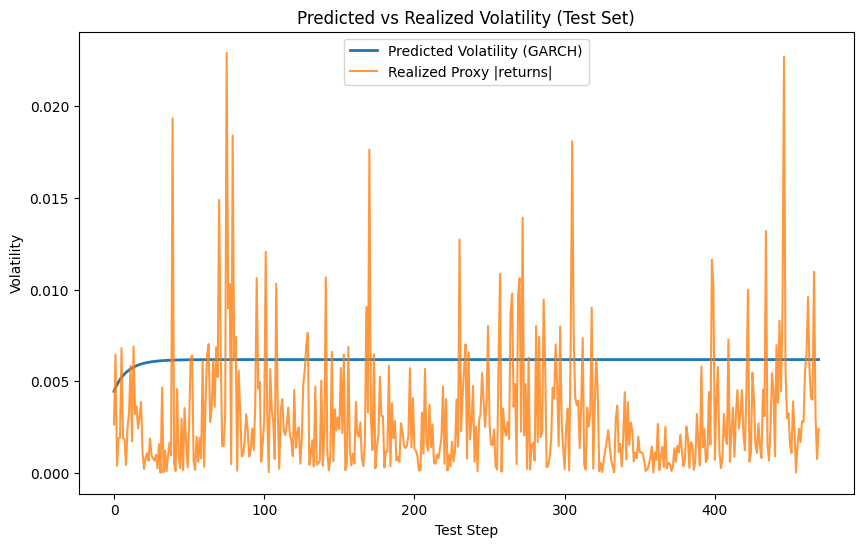

In [22]:
# Compare predicted vs realized volatility on test window
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(pred_vol, label='Predicted Volatility (GARCH)', linewidth=2)
ax.plot(realized_vol, label='Realized Proxy |returns|', linewidth=1.5, alpha=0.8)
ax.set_title('Predicted vs Realized Volatility (Test Set)')
ax.set_xlabel('Test Step')
ax.set_ylabel('Volatility')
ax.legend()
plt.show()

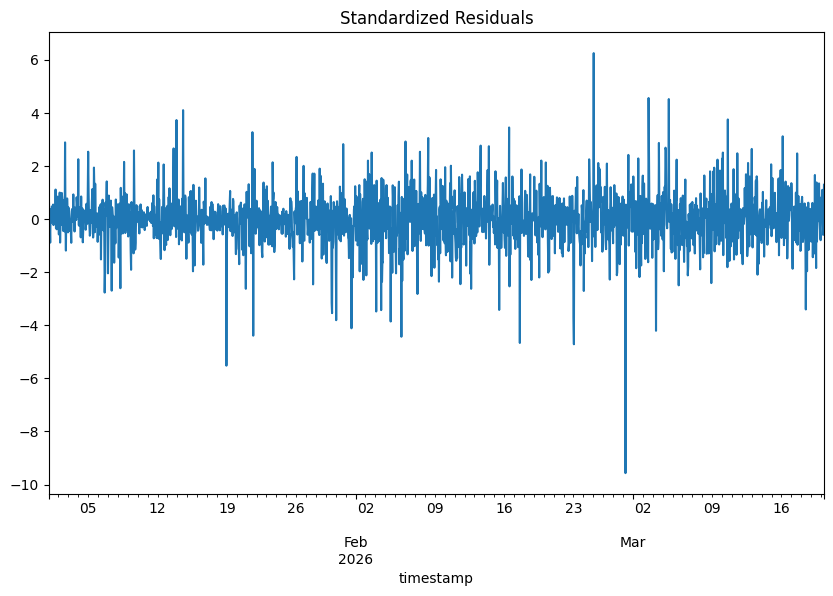

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
model_fit.std_resid.plot(ax=ax, title='Standardized Residuals')
plt.show()